In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay
import warnings
warnings.filterwarnings('ignore')


# Set random seed for reproducibility
np.random.seed(42)

In [133]:
print("GENERATING DATASET")
print("=" * 80)

# Generate a complex non-linear classification dataset
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    flip_y=0.1,  # Add 10% noise
    random_state=72
)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=72
)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: Class 0: {np.sum(y==0)}, Class 1: {np.sum(y==1)}")

GENERATING DATASET
Total samples: 500
Training samples: 350
Test samples: 150
Number of features: 2
Number of classes: 2
Class distribution: Class 0: 245, Class 1: 255


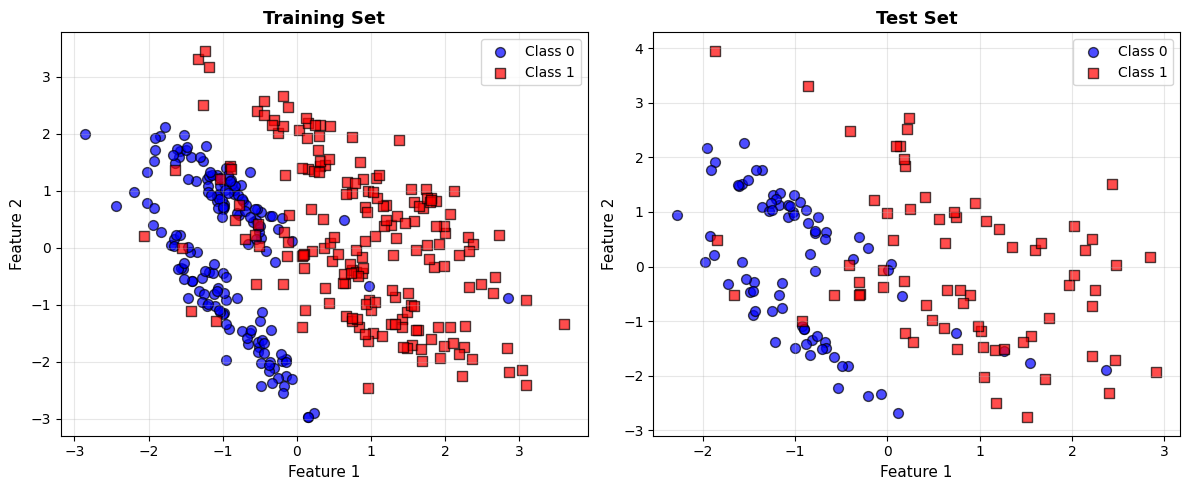


✓ Dataset visualization complete!
  Note: This is a challenging dataset with non-linear boundaries and noise


In [134]:
plt.figure(figsize=(12, 5))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
            c='blue', marker='o', s=50, alpha=0.7, edgecolors='k', label='Class 0')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
            c='red', marker='s', s=50, alpha=0.7, edgecolors='k', label='Class 1')
plt.xlabel('Feature 1', fontsize=11)
plt.ylabel('Feature 2', fontsize=11)
plt.title('Training Set', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Test set
plt.subplot(1, 2, 2)
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
            c='blue', marker='o', s=50, alpha=0.7, edgecolors='k', label='Class 0')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
            c='red', marker='s', s=50, alpha=0.7, edgecolors='k', label='Class 1')
plt.xlabel('Feature 1', fontsize=11)
plt.ylabel('Feature 2', fontsize=11)
plt.title('Test Set', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Dataset visualization complete!")
print("  Note: This is a challenging dataset with non-linear boundaries and noise")

In [135]:
print("\n" + "=" * 80)
print("BASELINE: SINGLE DECISION TREE")
print("=" * 80)

# Train a single decision tree (our baseline)
baseline_tree = DecisionTreeClassifier(max_depth=3, random_state=43)
baseline_tree.fit(X_train, y_train)

# Predictions
y_train_pred_baseline = baseline_tree.predict(X_train)
y_test_pred_baseline = baseline_tree.predict(X_test)

# Calculate accuracy
train_acc_baseline = accuracy_score(y_train, y_train_pred_baseline)
test_acc_baseline = accuracy_score(y_test, y_test_pred_baseline)

print(f"Training Accuracy: {train_acc_baseline:.4f}")
print(f"Test Accuracy: {test_acc_baseline:.4f}")
print(f"Overfitting Gap: {train_acc_baseline - test_acc_baseline:.4f}")


BASELINE: SINGLE DECISION TREE
Training Accuracy: 0.9314
Test Accuracy: 0.8600
Overfitting Gap: 0.0714


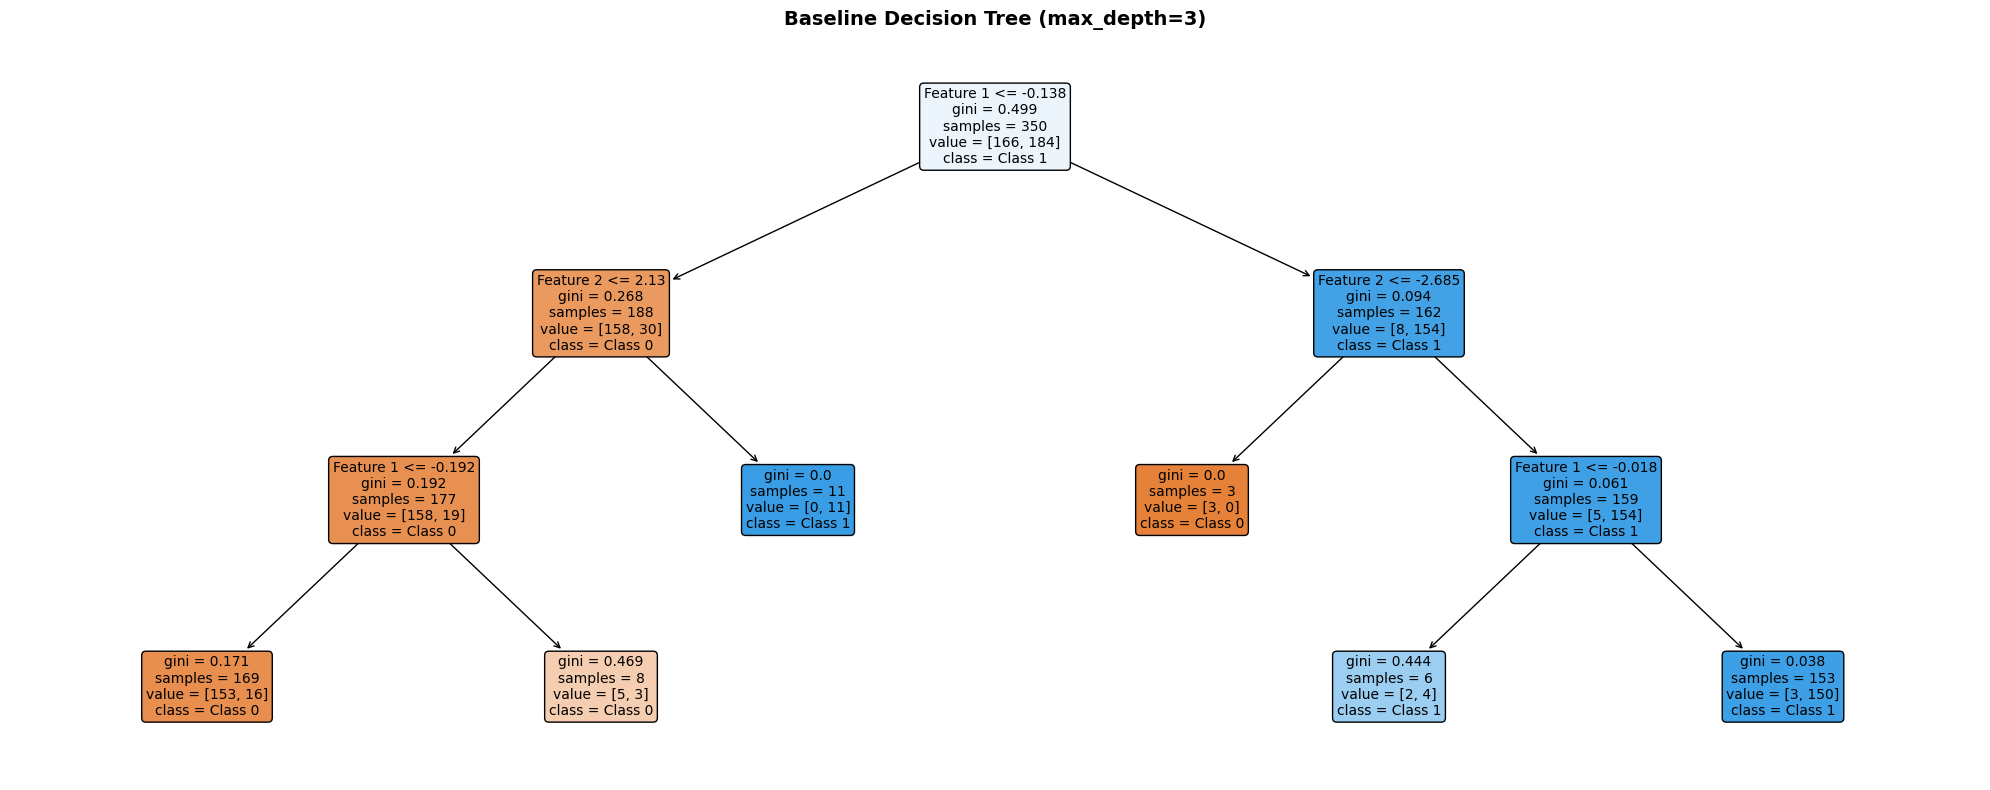

In [136]:
plt.figure(figsize=(20, 8))
plot_tree(baseline_tree, 
          feature_names=['Feature 1', 'Feature 2'],
          class_names=['Class 0', 'Class 1'],
          filled=True,
          fontsize=10,
          rounded=True)
plt.title('Baseline Decision Tree (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

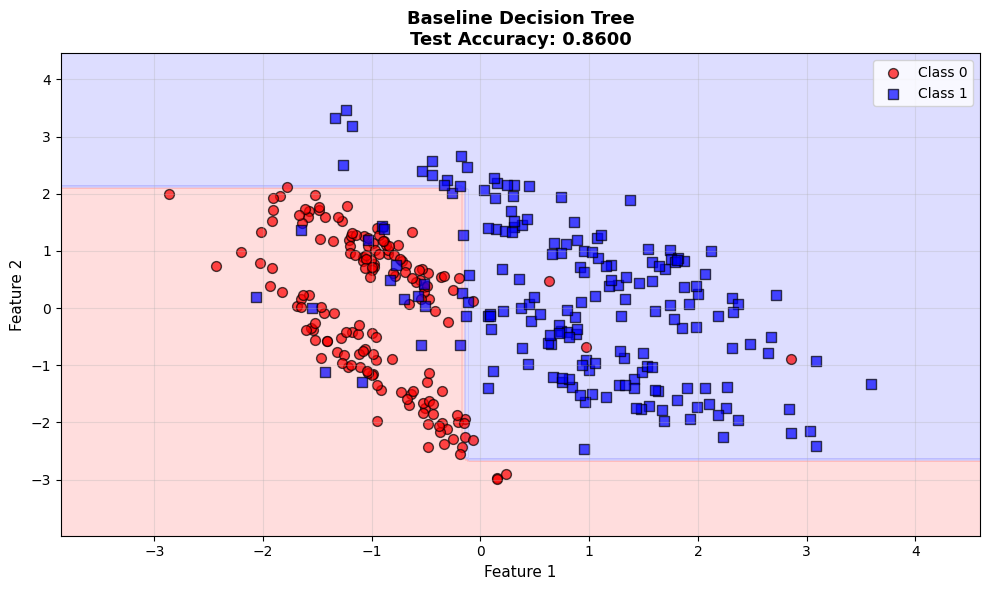

In [137]:
def plot_decision_boundary(clf, X, y, title, ax=None):
    """Plot decision boundary for a classifier"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ['red', 'blue']
    
    # Plot decision boundary
    DecisionBoundaryDisplay.from_estimator(
        clf, X, cmap=cmap_light, alpha=0.4, ax=ax, response_method='predict'
    )
    
    # Plot data points
    for idx, label in enumerate(np.unique(y)):
        ax.scatter(X[y==label, 0], X[y==label, 1],
                  c=cmap_bold[idx], marker='o' if label==0 else 's',
                  s=50, alpha=0.7, edgecolors='k', label=f'Class {label}')
    
    ax.set_xlabel('Feature 1', fontsize=11)
    ax.set_ylabel('Feature 2', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return ax

# Plot baseline decision boundary
plot_decision_boundary(baseline_tree, X_train, y_train, 
                      f'Baseline Decision Tree\nTest Accuracy: {test_acc_baseline:.4f}')
plt.tight_layout()
plt.show()

In [138]:
print("\n" + "=" * 80)
print("BAGGING (BOOTSTRAP AGGREGATING)")
print("=" * 80)

# Train Bagging classifier
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    max_samples=0.8,  # Use 80% of data for each bootstrap sample
    max_features=1.0,
    bootstrap=True,
    random_state=43,
    n_jobs=-1
)

bagging_clf.fit(X_train, y_train)

# Predictions
y_train_pred_bagging = bagging_clf.predict(X_train)
y_test_pred_bagging = bagging_clf.predict(X_test)

# Calculate accuracy
train_acc_bagging = accuracy_score(y_train, y_train_pred_bagging)
test_acc_bagging = accuracy_score(y_test, y_test_pred_bagging)

print(f"\nNumber of estimators: {bagging_clf.n_estimators}")
print(f"Training Accuracy: {train_acc_bagging:.4f}")
print(f"Test Accuracy: {test_acc_bagging:.4f}")
print(f"Overfitting Gap: {train_acc_bagging - test_acc_bagging:.4f}")
print(f"\nImprovement over baseline: {test_acc_bagging - test_acc_baseline:.4f}")


BAGGING (BOOTSTRAP AGGREGATING)

Number of estimators: 50
Training Accuracy: 0.9400
Test Accuracy: 0.8800
Overfitting Gap: 0.0600

Improvement over baseline: 0.0200


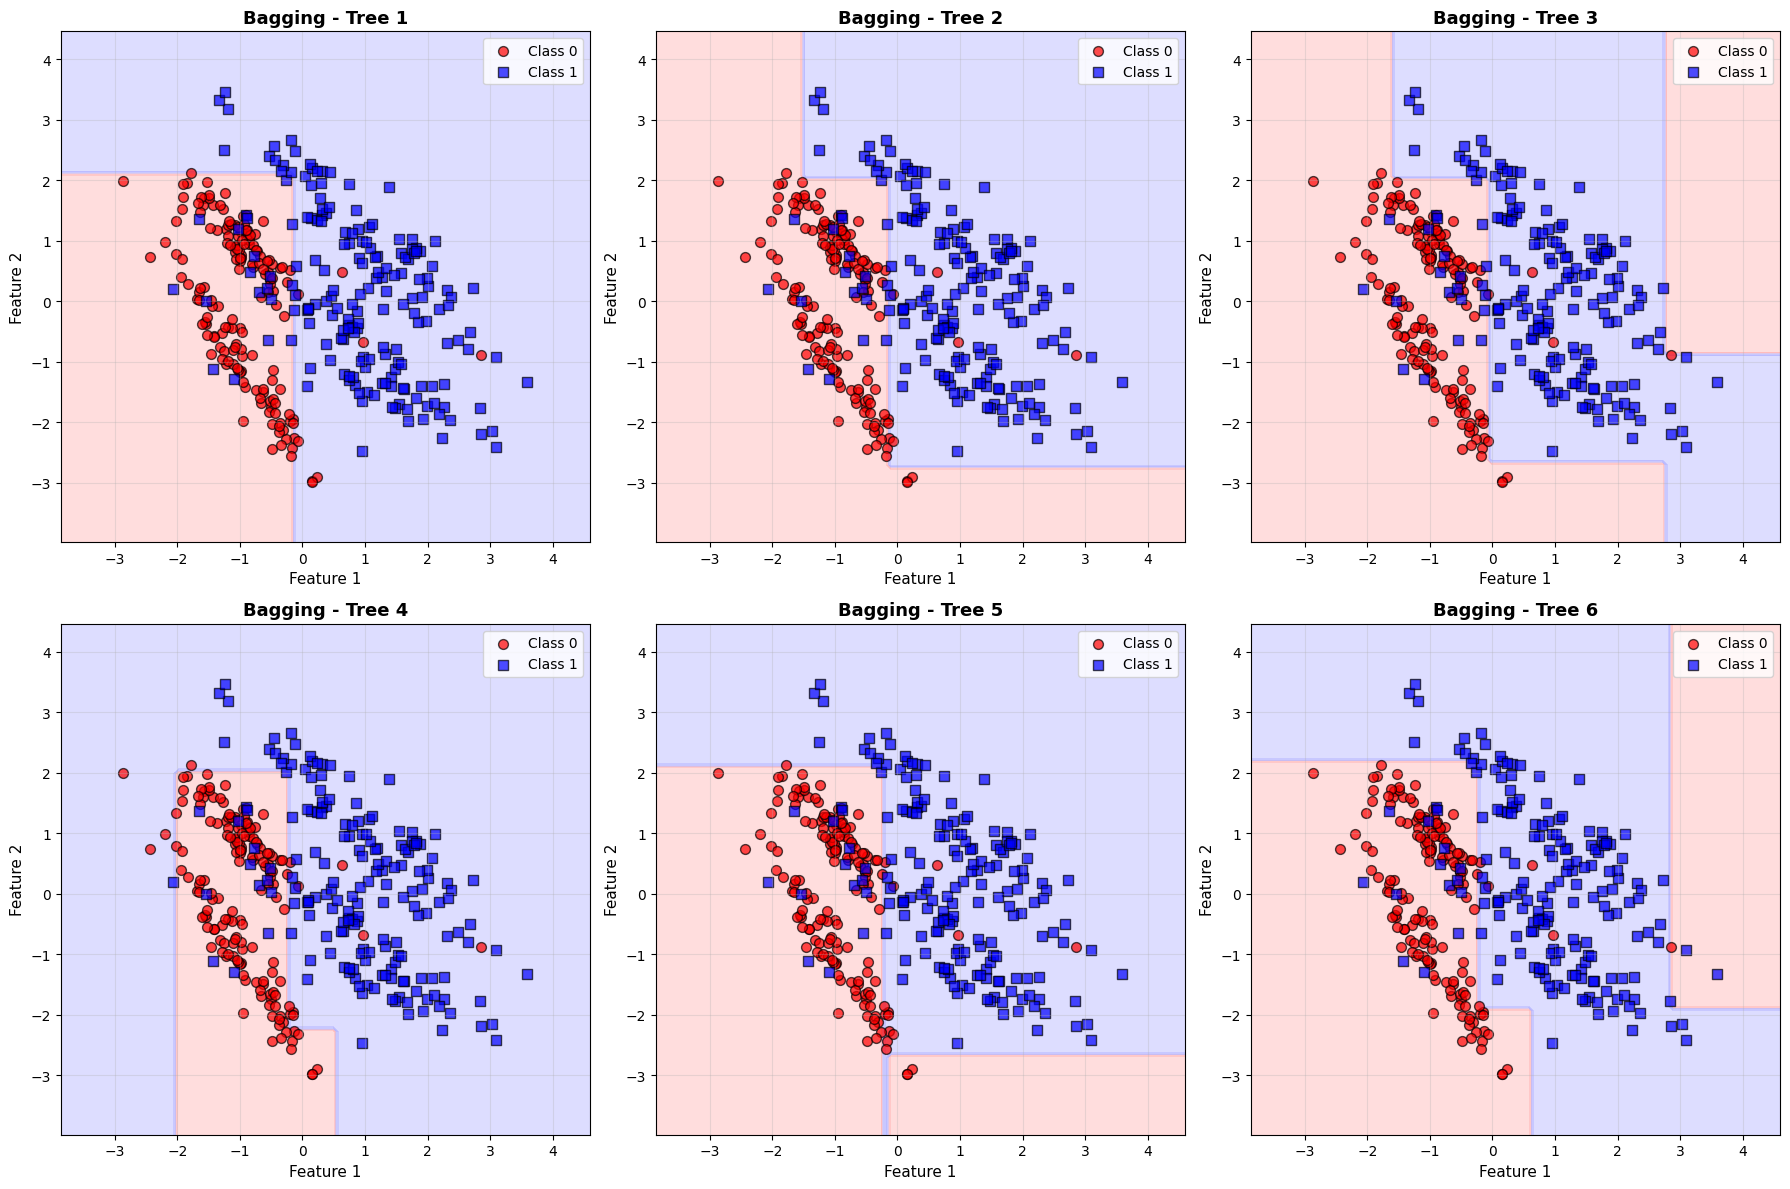

✓ Each tree sees different bootstrap sample and makes different mistakes
  Averaging reduces variance!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx in range(6):
    tree = bagging_clf.estimators_[idx]
    plot_decision_boundary(tree, X_train, y_train, 
                          f'Bagging - Tree {idx+1}', ax=axes[idx])

plt.tight_layout()
plt.show()

print("✓ Each tree sees different bootstrap sample and makes different mistakes")
print("  Averaging reduces variance!")

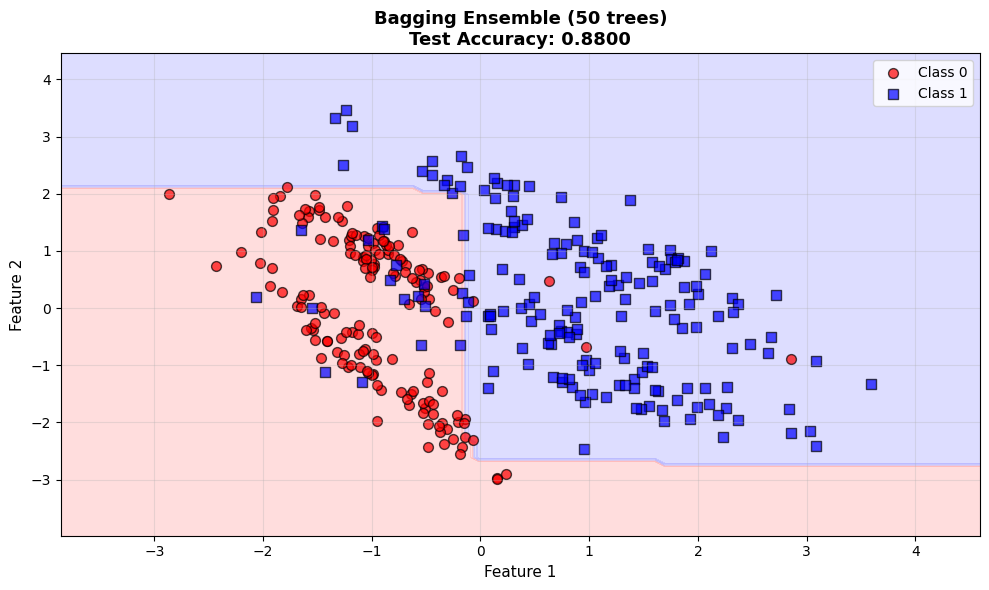

In [140]:
plot_decision_boundary(bagging_clf, X_train, y_train, 
                      f'Bagging Ensemble (50 trees)\nTest Accuracy: {test_acc_bagging:.4f}')
plt.tight_layout()
plt.show()


Analyzing effect of number of estimators...


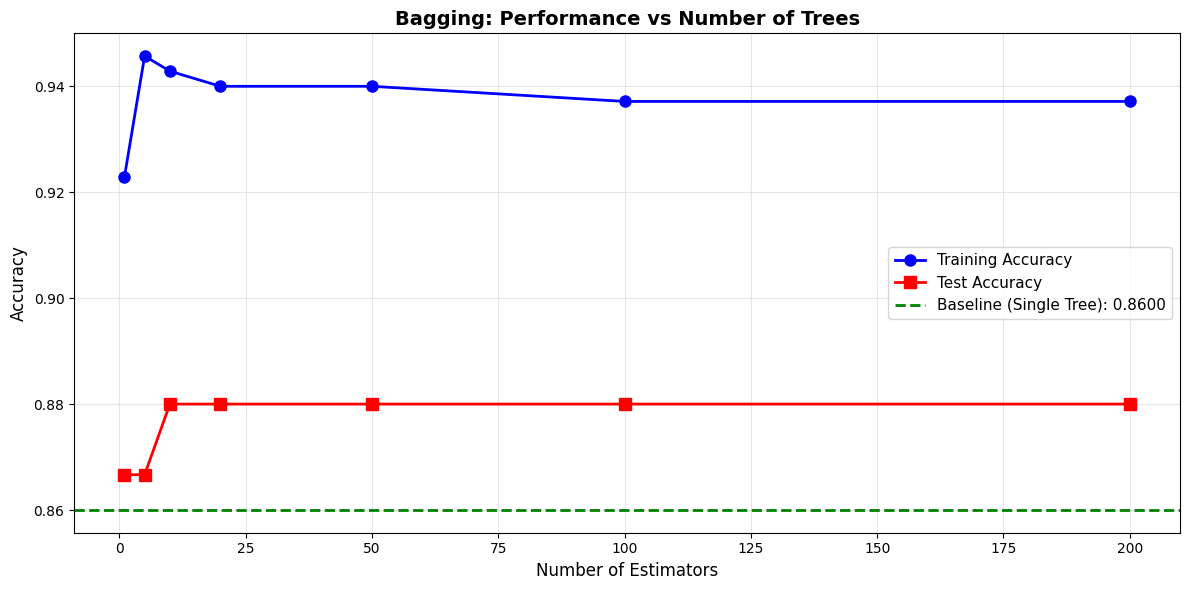

✓ Test accuracy stabilizes around 20-50 trees


In [141]:
print("\nAnalyzing effect of number of estimators...")

n_estimators_range = [1, 5, 10, 20, 50, 100, 200]
train_scores_bagging = []
test_scores_bagging = []

for n_est in n_estimators_range:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=n_est,
        max_samples=0.8,
        random_state=43,
        n_jobs=-1
    )
    bag.fit(X_train, y_train)
    train_scores_bagging.append(accuracy_score(y_train, bag.predict(X_train)))
    test_scores_bagging.append(accuracy_score(y_test, bag.predict(X_test)))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, train_scores_bagging, 'o-', linewidth=2, 
         markersize=8, label='Training Accuracy', color='blue')
plt.plot(n_estimators_range, test_scores_bagging, 's-', linewidth=2, 
         markersize=8, label='Test Accuracy', color='red')
plt.axhline(y=test_acc_baseline, color='green', linestyle='--', 
            linewidth=2, label=f'Baseline (Single Tree): {test_acc_baseline:.4f}')
plt.xlabel('Number of Estimators', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Bagging: Performance vs Number of Trees', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✓ Test accuracy stabilizes around {n_estimators_range[3]}-{n_estimators_range[4]} trees")

In [142]:
print("\n" + "=" * 80)
print("ADABOOST (ADAPTIVE BOOSTING)")
print("=" * 80)

# Train AdaBoost classifier
adaboost_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    learning_rate=1.0,
    random_state=43
)

adaboost_clf.fit(X_train, y_train)

# Predictions
y_train_pred_adaboost = adaboost_clf.predict(X_train)
y_test_pred_adaboost = adaboost_clf.predict(X_test)

# Calculate accuracy
train_acc_adaboost = accuracy_score(y_train, y_train_pred_adaboost)
test_acc_adaboost = accuracy_score(y_test, y_test_pred_adaboost)

print(f"\nNumber of estimators: {adaboost_clf.n_estimators}")
print(f"Learning rate: {adaboost_clf.learning_rate}")
print(f"Training Accuracy: {train_acc_adaboost:.4f}")
print(f"Test Accuracy: {test_acc_adaboost:.4f}")
print(f"Overfitting Gap: {train_acc_adaboost - test_acc_adaboost:.4f}")
print(f"\nImprovement over baseline: {test_acc_adaboost - test_acc_baseline:.4f}")


ADABOOST (ADAPTIVE BOOSTING)

Number of estimators: 50
Learning rate: 1.0
Training Accuracy: 1.0000
Test Accuracy: 0.8733
Overfitting Gap: 0.1267

Improvement over baseline: 0.0133


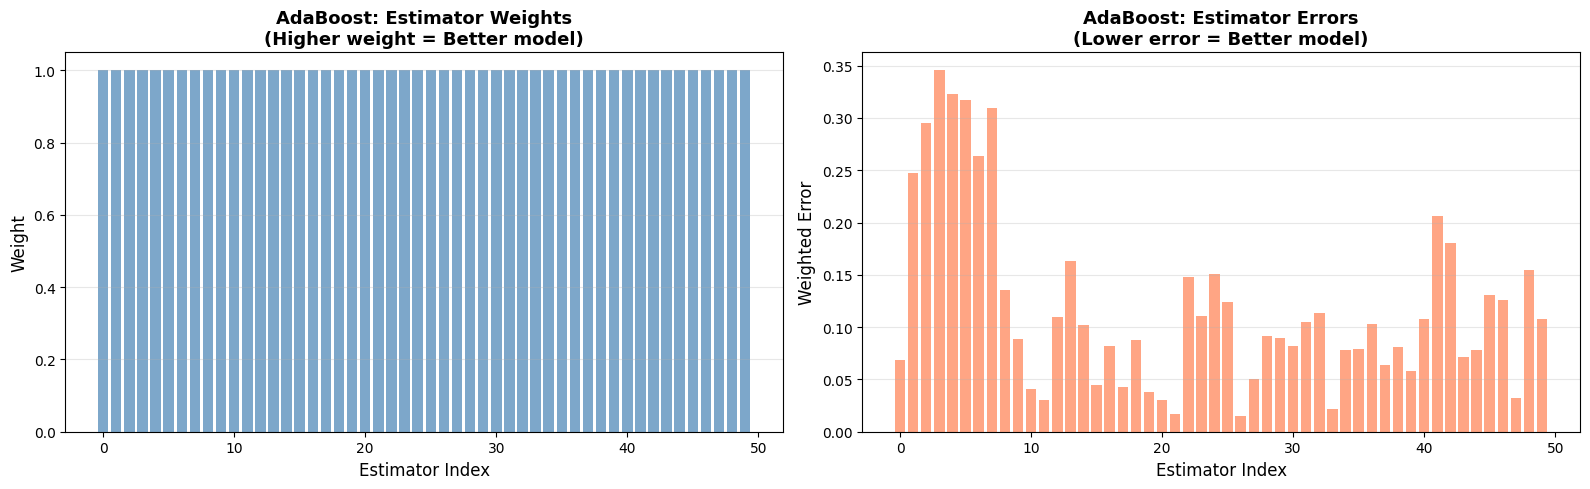

✓ Better models (lower error) get higher weights in final prediction
✓ AdaBoost automatically identifies which models to trust more


In [143]:
# Visualize estimator weights (how much each model contributes)
estimator_weights = adaboost_clf.estimator_weights_
estimator_errors = adaboost_clf.estimator_errors_

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Estimator weights
axes[0].bar(range(len(estimator_weights)), estimator_weights, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Estimator Index', fontsize=12)
axes[0].set_ylabel('Weight', fontsize=12)
axes[0].set_title('AdaBoost: Estimator Weights\n(Higher weight = Better model)', 
                  fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Estimator errors
axes[1].bar(range(len(estimator_errors)), estimator_errors, color='coral', alpha=0.7)
axes[1].set_xlabel('Estimator Index', fontsize=12)
axes[1].set_ylabel('Weighted Error', fontsize=12)
axes[1].set_title('AdaBoost: Estimator Errors\n(Lower error = Better model)', 
                  fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Better models (lower error) get higher weights in final prediction")
print("✓ AdaBoost automatically identifies which models to trust more")

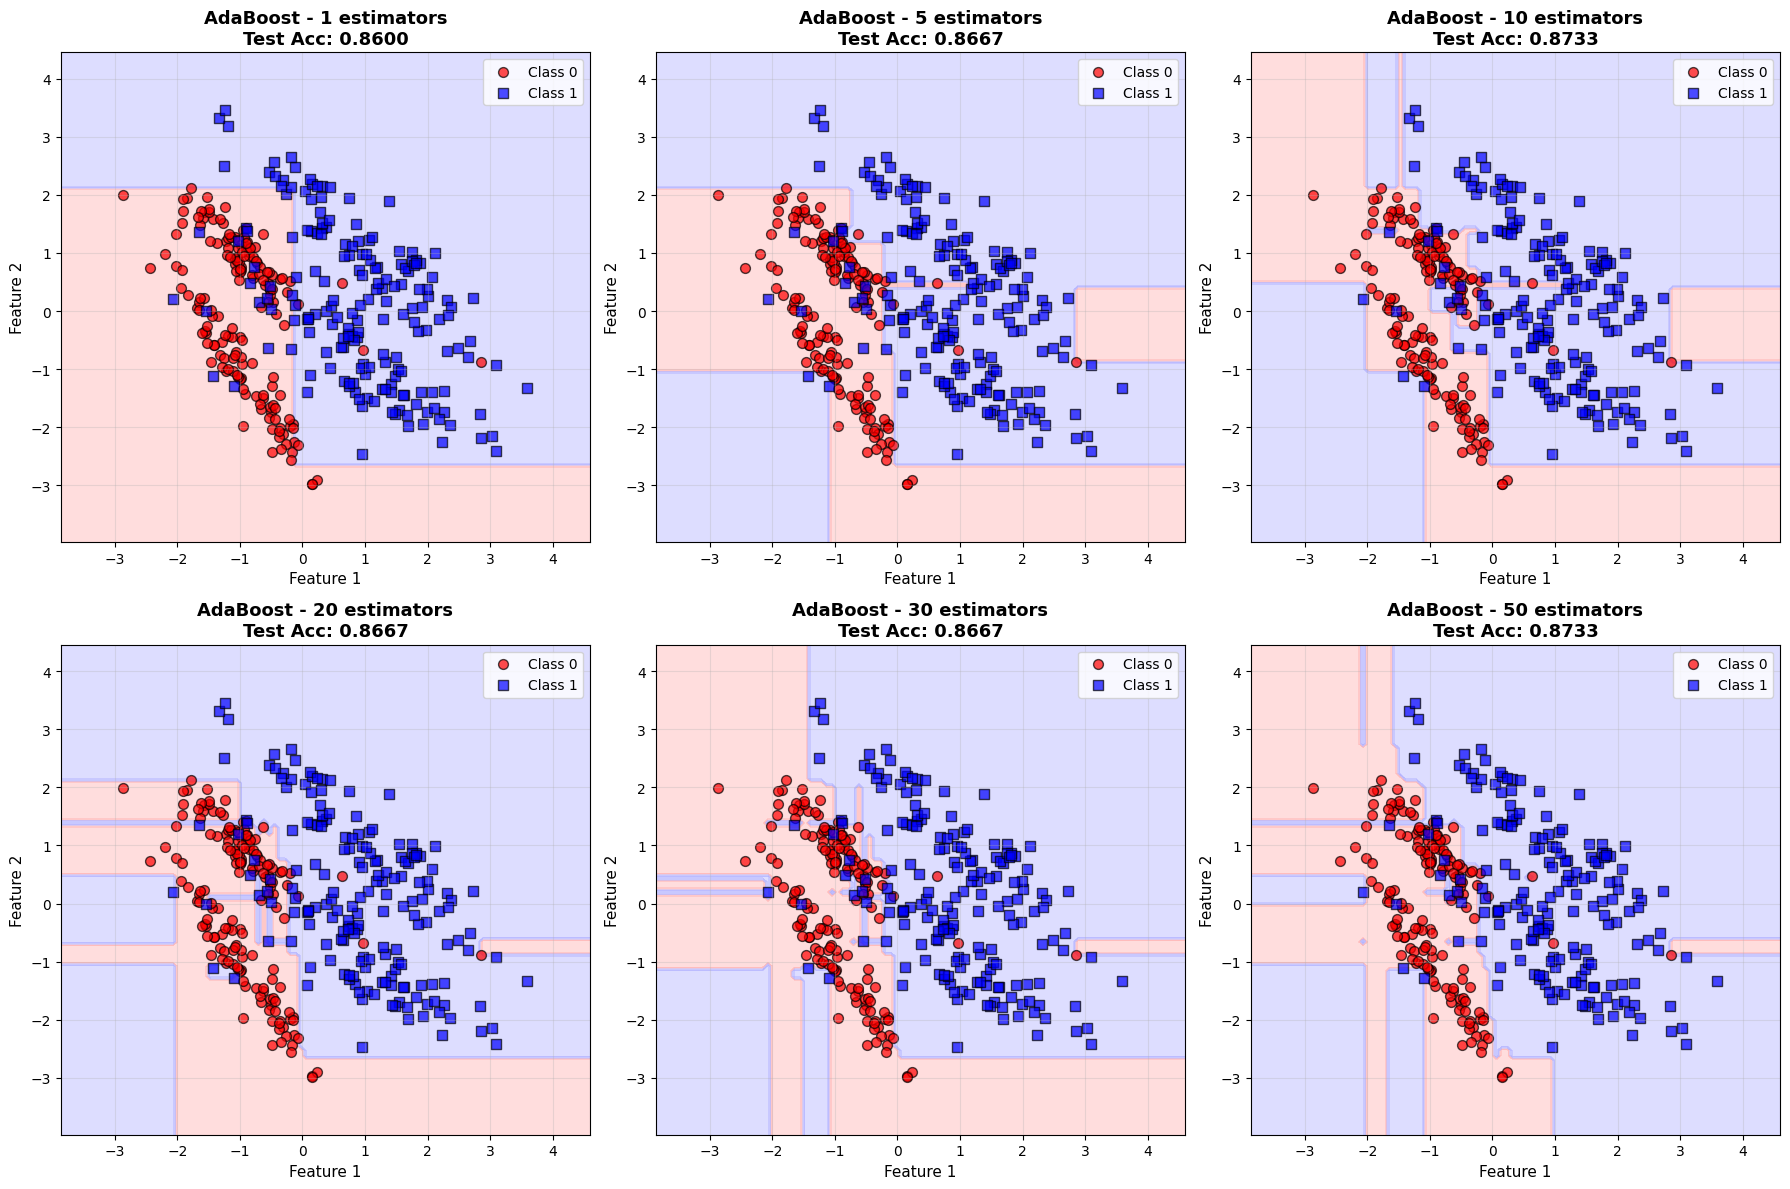

✓ AdaBoost adapts to focus on difficult regions
  Boundary becomes more refined around complex areas!


In [ ]:
# Show how AdaBoost evolves
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

iterations_to_show = [1, 5, 10, 20, 30, 50]

for idx, n_est in enumerate(iterations_to_show):
    temp_clf = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=n_est,
        learning_rate=1.0,
        random_state=43
    )
    temp_clf.fit(X_train, y_train)
    test_acc_temp = accuracy_score(y_test, temp_clf.predict(X_test))
    
    plot_decision_boundary(temp_clf, X_train, y_train, 
                          f'AdaBoost - {n_est} estimators\nTest Acc: {test_acc_temp:.4f}', 
                          ax=axes[idx])

plt.tight_layout()
plt.show()

print("✓ AdaBoost adapts to focus on difficult regions")
print("  Boundary becomes more refined around complex areas!")


COMPREHENSIVE COMPARISON


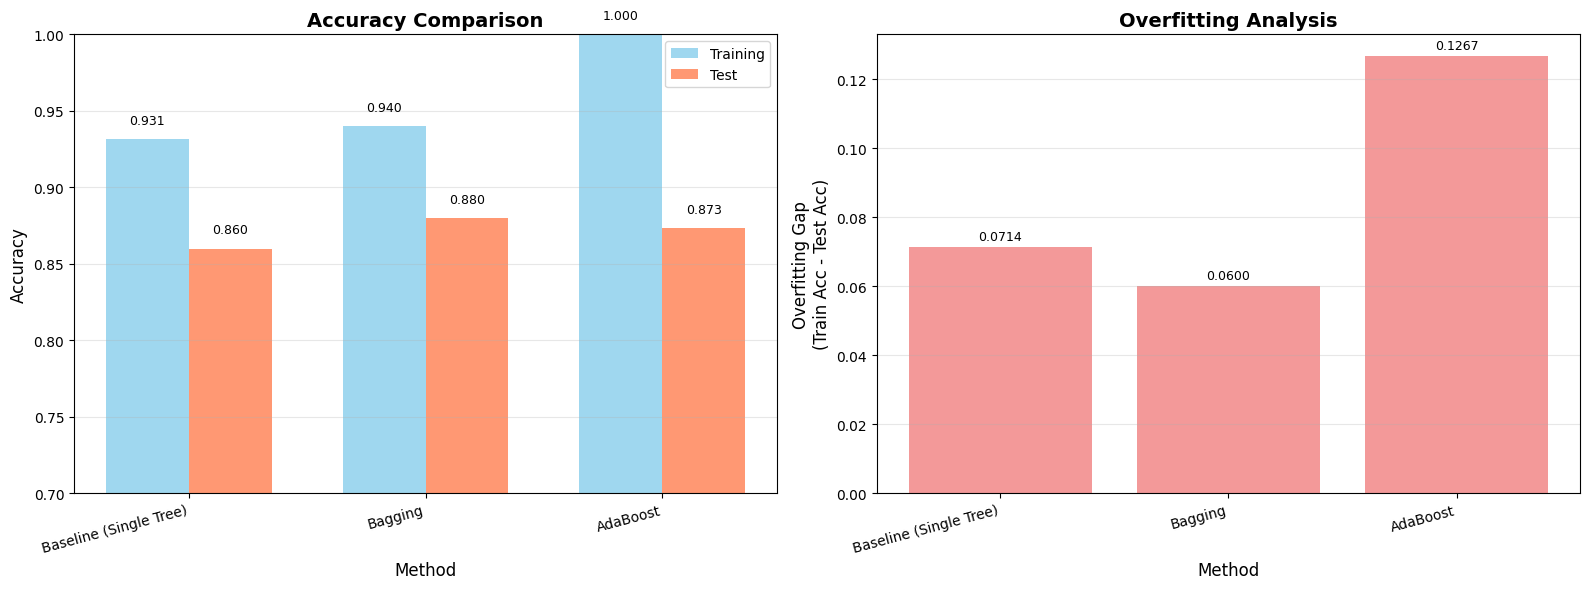


SUMMARY TABLE:
--------------------------------------------------------------------------------
Method                    Train Acc    Test Acc     Overfit Gap 
--------------------------------------------------------------------------------
Baseline (Single Tree)    0.9314       0.8600       0.0714      
Bagging                   0.9400       0.8800       0.0600      
AdaBoost                  1.0000       0.8733       0.1267      
--------------------------------------------------------------------------------


In [145]:
print("\n" + "=" * 80)
print("COMPREHENSIVE COMPARISON")
print("=" * 80)

# Create comparison dataframe
methods = ['Baseline (Single Tree)', 'Bagging', 'AdaBoost']
train_accs = [train_acc_baseline, train_acc_bagging, train_acc_adaboost]
test_accs = [test_acc_baseline, test_acc_bagging, test_acc_adaboost]
overfit_gaps = [train_acc_baseline - test_acc_baseline,
                train_acc_bagging - test_acc_bagging,
                train_acc_adaboost - test_acc_adaboost]

# Bar plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
x = np.arange(len(methods))
width = 0.35

axes[0].bar(x - width/2, train_accs, width, label='Training', color='skyblue', alpha=0.8)
axes[0].bar(x + width/2, test_accs, width, label='Test', color='coral', alpha=0.8)
axes[0].set_xlabel('Method', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0.7, 1.0])

# Add value labels
for i, (train, test) in enumerate(zip(train_accs, test_accs)):
    axes[0].text(i - width/2, train + 0.01, f'{train:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, test + 0.01, f'{test:.3f}', ha='center', fontsize=9)

# Overfitting gap
axes[1].bar(methods, overfit_gaps, color='lightcoral', alpha=0.8)
axes[1].set_xlabel('Method', fontsize=12)
axes[1].set_ylabel('Overfitting Gap\n(Train Acc - Test Acc)', fontsize=12)
axes[1].set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(methods, rotation=15, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add value labels
for i, gap in enumerate(overfit_gaps):
    axes[1].text(i, gap + 0.002, f'{gap:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary table
print("\nSUMMARY TABLE:")
print("-" * 80)
print(f"{'Method':<25} {'Train Acc':<12} {'Test Acc':<12} {'Overfit Gap':<12}")
print("-" * 80)
for method, train, test, gap in zip(methods, train_accs, test_accs, overfit_gaps):
    print(f"{method:<25} {train:<12.4f} {test:<12.4f} {gap:<12.4f}")
print("-" * 80)

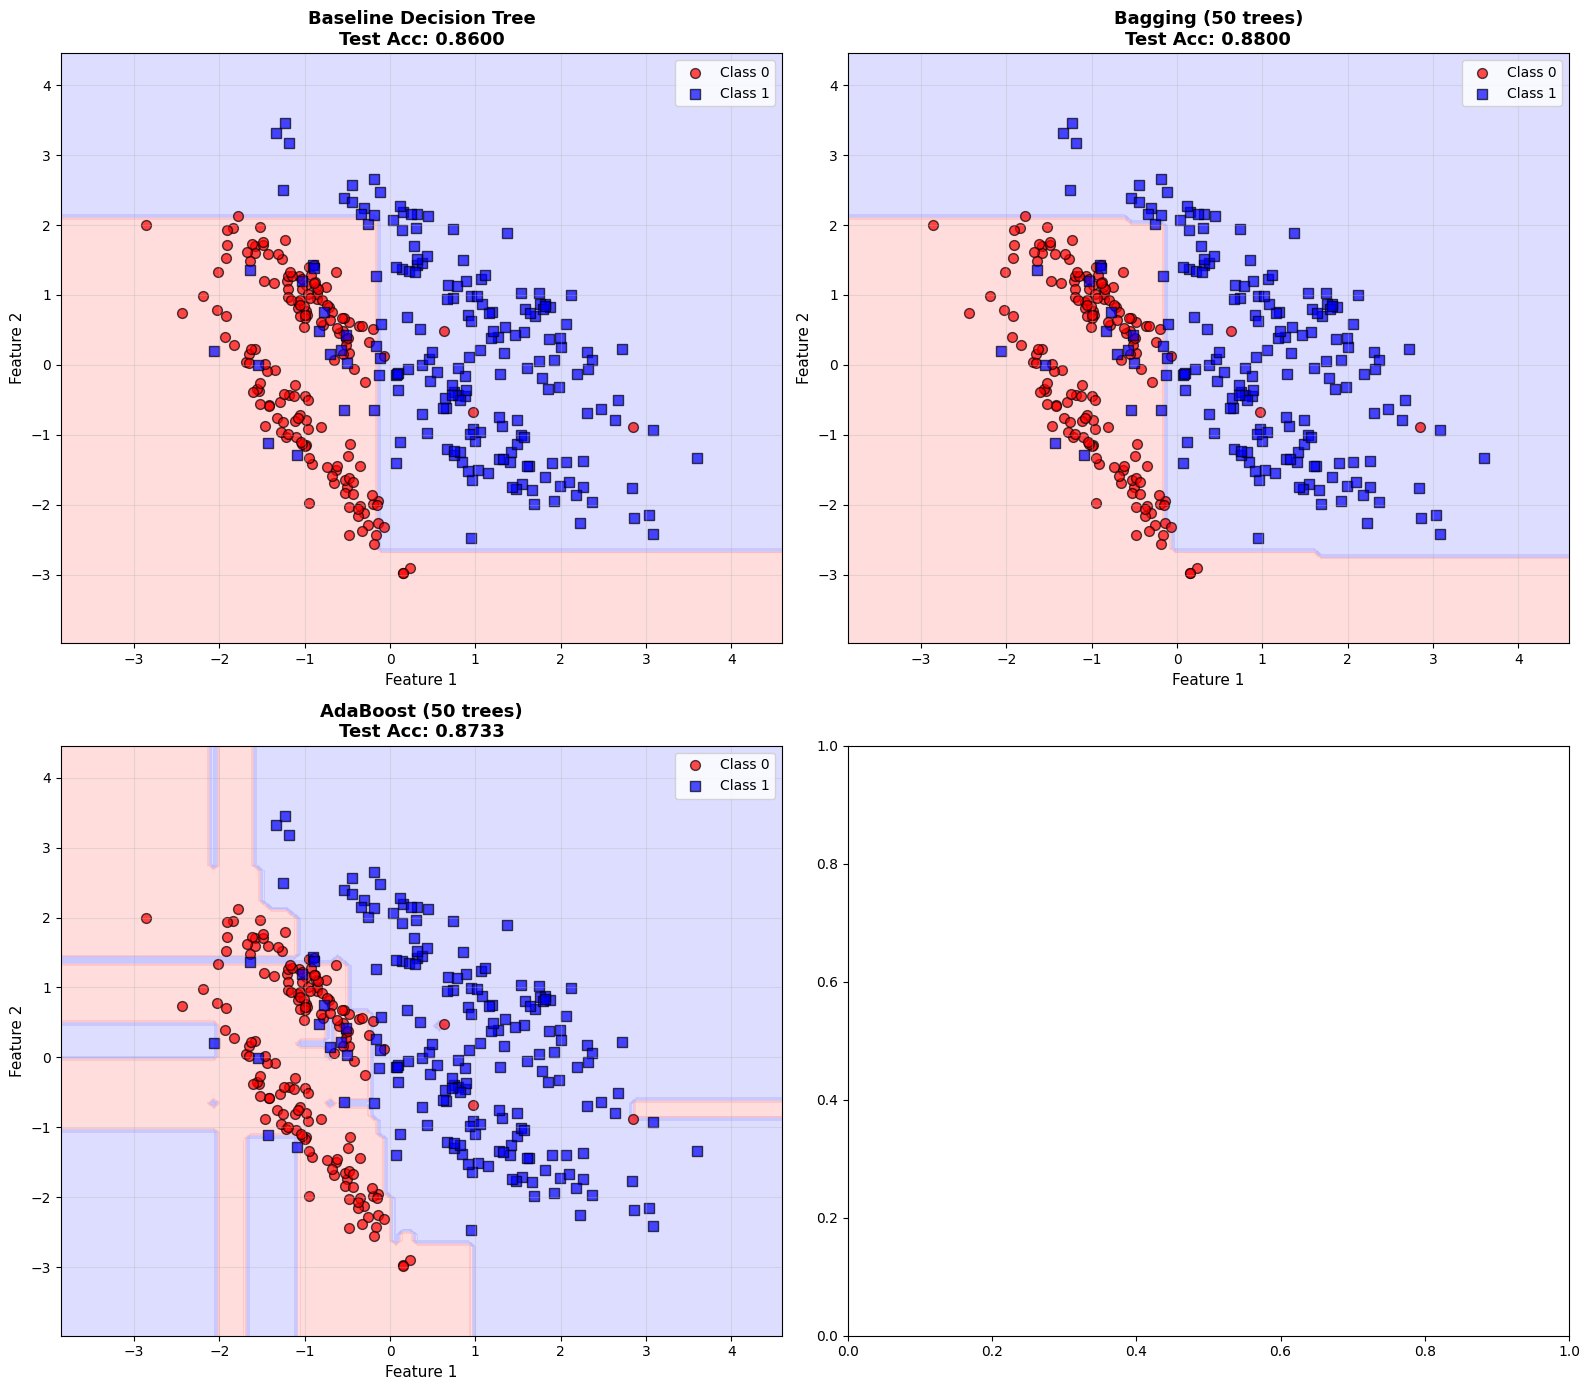

✓ Visual comparison shows how each method handles the decision boundary


In [146]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

classifiers = [baseline_tree, bagging_clf, adaboost_clf]
titles = [f'Baseline Decision Tree\nTest Acc: {test_acc_baseline:.4f}',
          f'Bagging (50 trees)\nTest Acc: {test_acc_bagging:.4f}',
          f'AdaBoost (50 trees)\nTest Acc: {test_acc_adaboost:.4f}']

for ax, clf, title in zip(axes, classifiers, titles):
    plot_decision_boundary(clf, X_train, y_train, title, ax=ax)

plt.tight_layout()
plt.show()

print("✓ Visual comparison shows how each method handles the decision boundary")


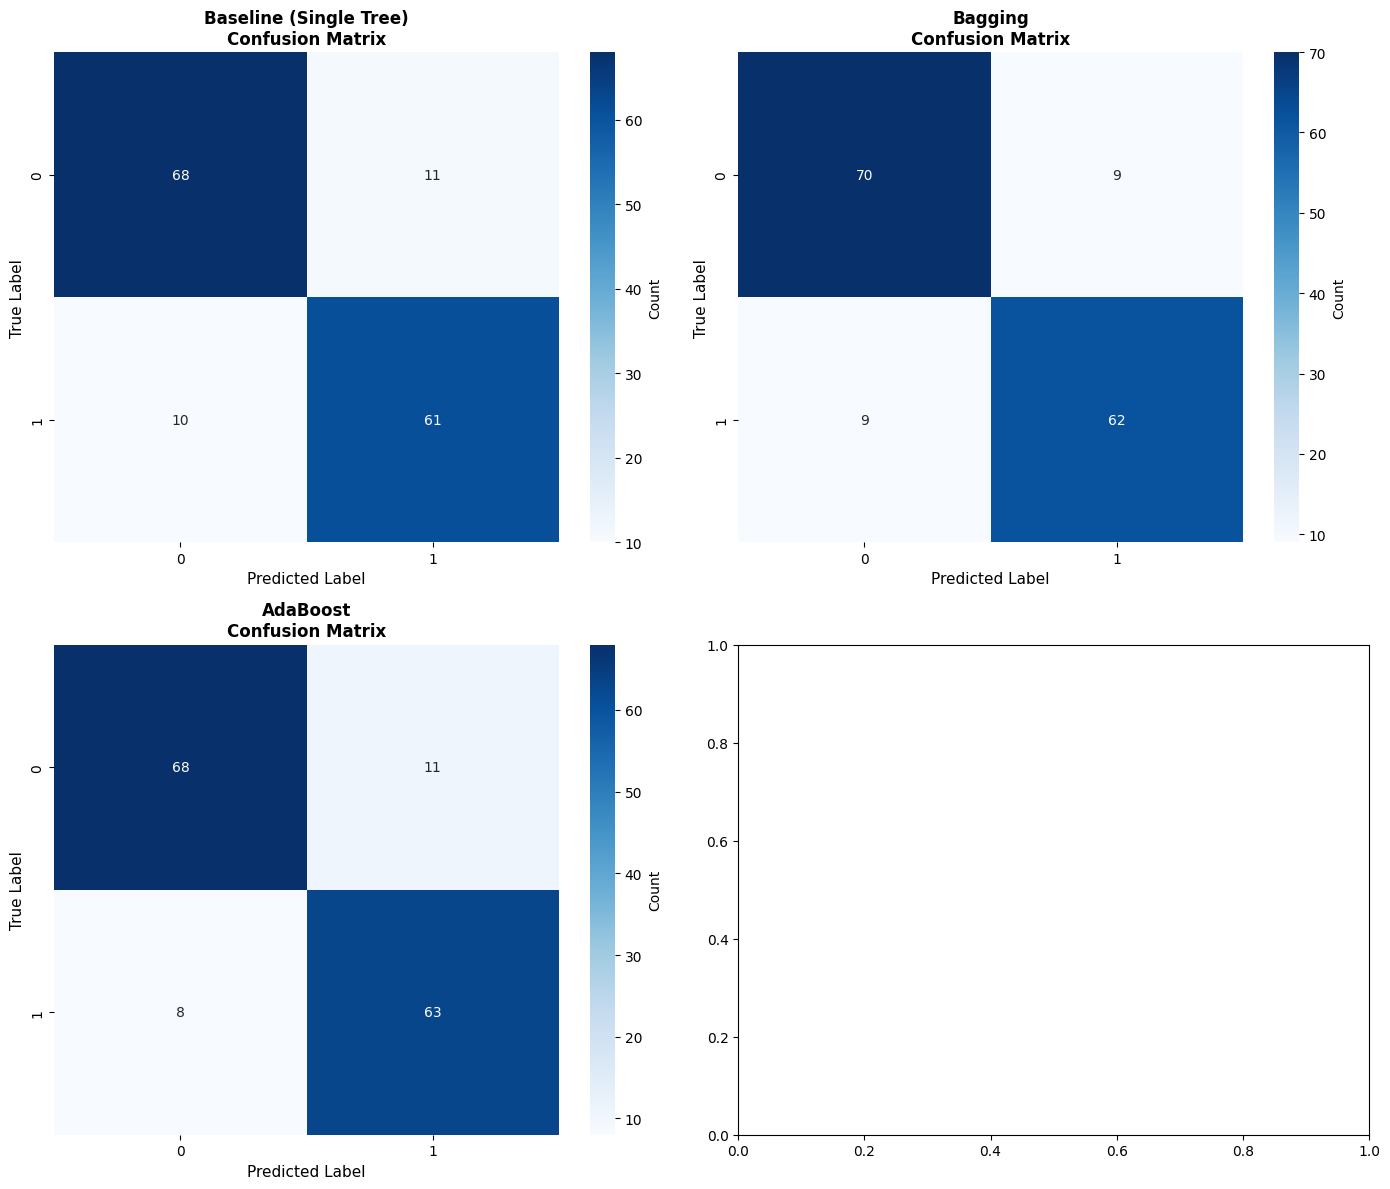

In [147]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

predictions = [y_test_pred_baseline, y_test_pred_bagging, y_test_pred_adaboost]

for ax, pred, method in zip(axes, predictions, methods):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'{method}\nConfusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()